First 5 rows:
    Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     68.95   35     61833.90                256.09   
1                     80.23   31     68441.85                193.77   
2                     69.47   26     59785.94                236.50   
3                     74.15   29     54806.18                245.89   
4                     68.37   35     73889.99                225.58   

                           Ad Topic Line            City  Male     Country  \
0     Cloned 5thgeneration orchestration     Wrightburgh     0     Tunisia   
1     Monitored national standardization       West Jodi     1       Nauru   
2       Organic bottom-line service-desk        Davidton     0  San Marino   
3  Triple-buffered reciprocal time-frame  West Terrifurt     1       Italy   
4          Robust logistical utilization    South Manuel     0     Iceland   

             Timestamp  Clicked on Ad  
0  2016-03-27 00:53:11              0  
1  2016-0

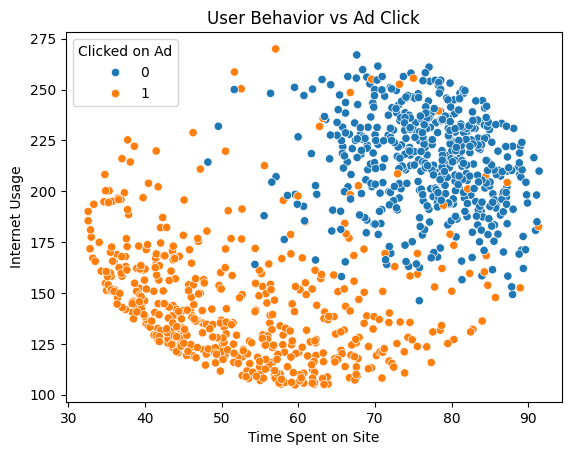

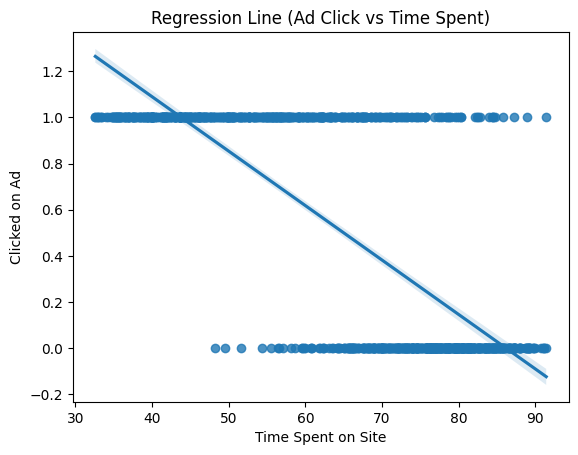


Confusion Matrix:
 [[143   3]
 [  6 148]]


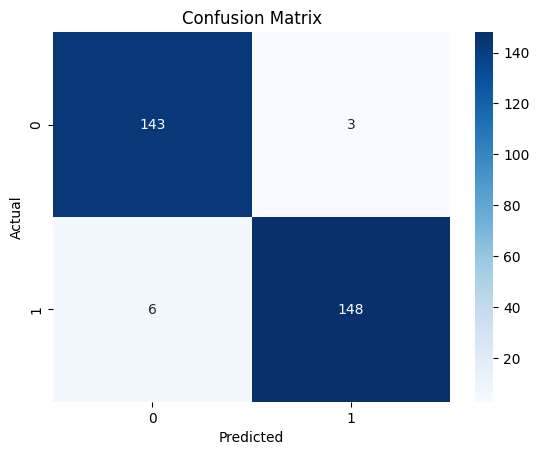


True Positive (TP): 148
True Negative (TN): 143
False Positive (FP): 3
False Negative (FN): 6

Accuracy: 0.97
Error Rate: 0.030000000000000027
Precision: 0.9801324503311258
Recall: 0.961038961038961


In [4]:
# ==============================
# Logistic Regression - Advertising Dataset (BEST VERSION)
# ==============================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset
df = pd.read_csv("advertising.csv")

print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())
print("\nStatistical Summary:\n", df.describe())

# 3. Data Preprocessing
df = df.drop(['Ad Topic Line', 'City', 'Country', 'Timestamp'], axis=1)

print("\nMissing Values:\n", df.isnull().sum())

# ==============================
# IMPORTANT PLOT 1: Scatter Plot
# ==============================
sns.scatterplot(
    x='Daily Time Spent on Site',
    y='Daily Internet Usage',
    hue='Clicked on Ad',
    data=df
)
plt.title("User Behavior vs Ad Click")
plt.xlabel("Time Spent on Site")
plt.ylabel("Internet Usage")
plt.show()

# ==============================
# IMPORTANT PLOT 2: Regression Line (SAFE)
# ==============================
sns.regplot(
    x='Daily Time Spent on Site',
    y='Clicked on Ad',
    data=df
)
plt.title("Regression Line (Ad Click vs Time Spent)")
plt.xlabel("Time Spent on Site")
plt.ylabel("Clicked on Ad")
plt.show()

# 4. Define Features & Target
X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']

# 5. Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ==============================
# FIX: Scaling + Iterations
# ==============================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Logistic Regression Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 7. Predictions
y_pred = model.predict(X_test)

# 8. Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ==============================
# IMPORTANT PLOT 3: Confusion Matrix
# ==============================
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 9. TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()

print("\nTrue Positive (TP):", TP)
print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)

# 10. Performance Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)